# Parcial 2023 — RESUELTO

**Solución de referencia** generada y verificada por Claude (5/7/2026). Primero intentá resolverlo vos; las celdas **💬 Discusión** son el modelo de comentario que espera cada parte.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import astsadata as astsa
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

plt.rcParams['figure.figsize'] = [15, 5]
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.constrained_layout.use'] = True

def ccf(x, y, max_lag, ax=None, **kwargs):
    lags = np.arange(-max_lag, max_lag + 1)
    backwards = sm.tsa.ccf(x[::-1], y[::-1], adjusted=False)[max_lag::-1]
    forwards = sm.tsa.ccf(x, y, adjusted=False)[:max_lag + 1]
    ccf = np.r_[backwards[:-1], forwards]
    if ax is None:
        ax = plt.gca()
    ax.stem(lags, ccf, basefmt='k')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    conf_level = 1.96 / np.sqrt(x.shape[0])
    ax.fill_between(lags, conf_level, -conf_level, alpha=0.25)
    ax.set_xlabel('LAG')
    ax.set_ylabel('CCF')
    return ax

---
## Ejercicio 1 — `cpg`: costo de almacenamiento (Tipo A con transformación log)

Precio en USD/GB, anual 1980–2008. Se pide: (1) describir y argumentar descenso exponencial, (2) transformar a log, (3) regresión lineal, (4) ajuste y residuos, (5) término cuadrático y comparación.

### 1.1 Descripción y descenso exponencial

Primer valor: 213,000 USD/GB | Último: 0.07 USD/GB


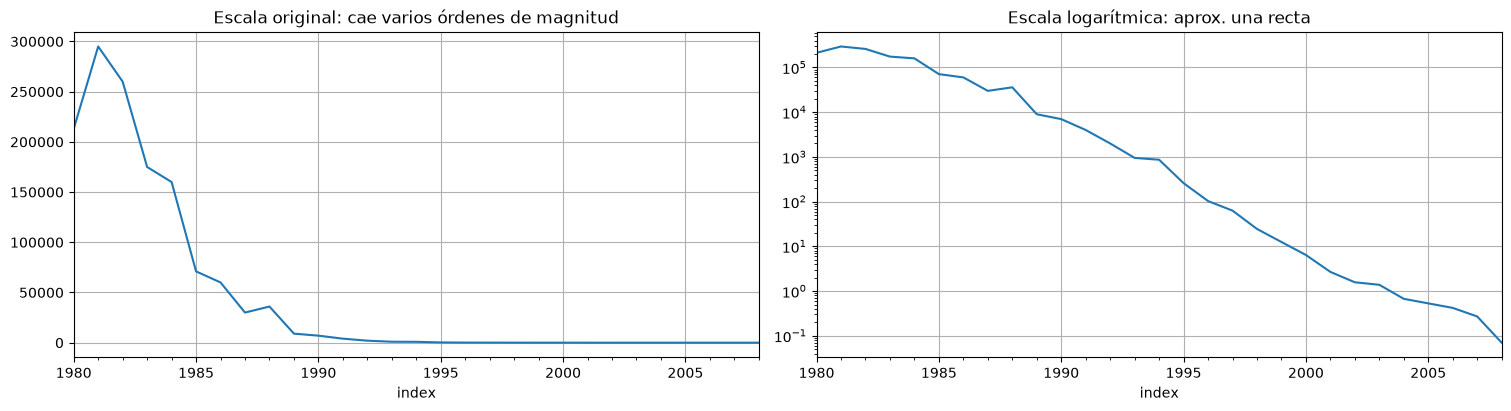

In [2]:
cpg = astsa.cpg.squeeze()
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
cpg.plot(ax=axs[0], title='Escala original: cae varios órdenes de magnitud')
cpg.plot(ax=axs[1], logy=True, title='Escala logarítmica: aprox. una recta')
print(f'Primer valor: {cpg.iloc[0]:,.0f} USD/GB | Último: {cpg.iloc[-1]:.2f} USD/GB')

**💬 Discusión 1.1** — El precio cae **varios órdenes de magnitud** en 29 años (de cientos de miles a menos de 1 USD/GB): en escala original la caída inicial aplasta todo el resto. Que en **escala logarítmica la serie se vea aproximadamente lineal** es exactamente el argumento de que el descenso es exponencial: si x_t ≈ A·e^(−bt), entonces log(x_t) ≈ log(A) − b·t, una recta.

### 1.2 Transformación logarítmica

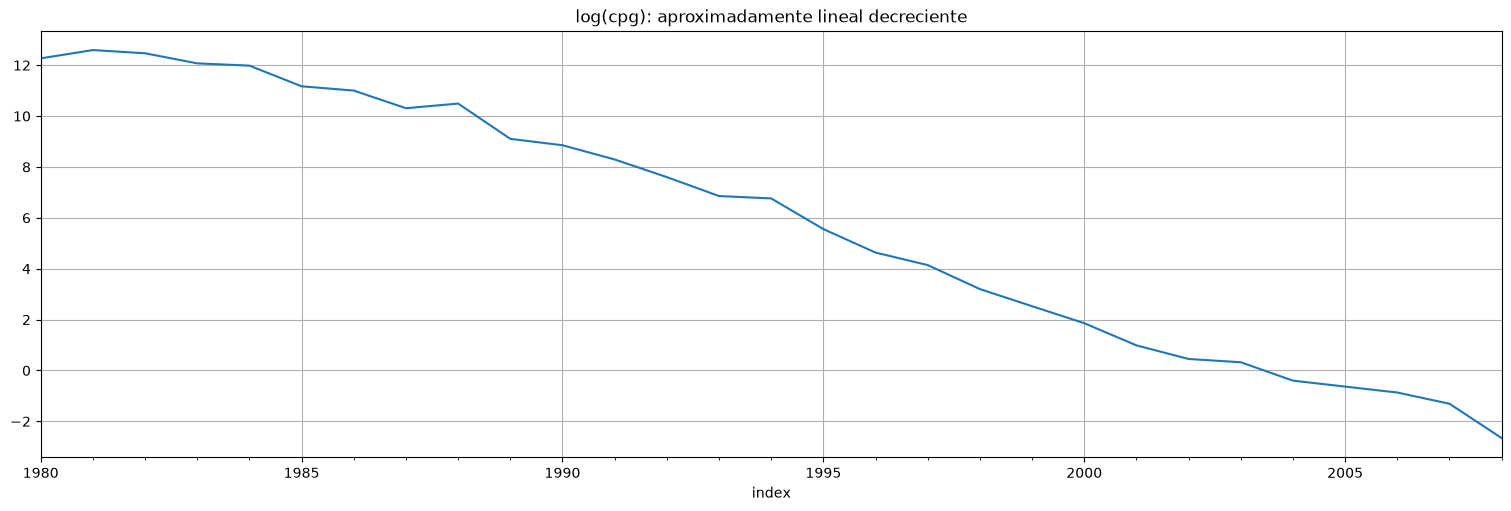

In [3]:
x = np.log(cpg)
x.plot(title='log(cpg): aproximadamente lineal decreciente');

**💬 Discusión 1.2** — En escala log la serie es casi una recta decreciente — confirma el decaimiento exponencial — aunque se insinúa **cierta curvatura** (la caída parece acelerarse en la década del 90), que motivará el término cuadrático de la parte 5.

### 1.3 Regresión lineal en el log

In [4]:
df = pd.DataFrame({'y': x.values, 't': np.arange(len(x))})
fit_lin = ols('y ~ t', data=df).fit()
print(fit_lin.summary().tables[1])
print()
print(f'R2 = {fit_lin.rsquared:.4f} | AIC = {fit_lin.aic:.1f}')

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     14.0406      0.226     62.246      0.000      13.578      14.503
t             -0.5851      0.014    -42.304      0.000      -0.613      -0.557

R2 = 0.9851 | AIC = 56.8


### 1.4 Ajuste y residuos

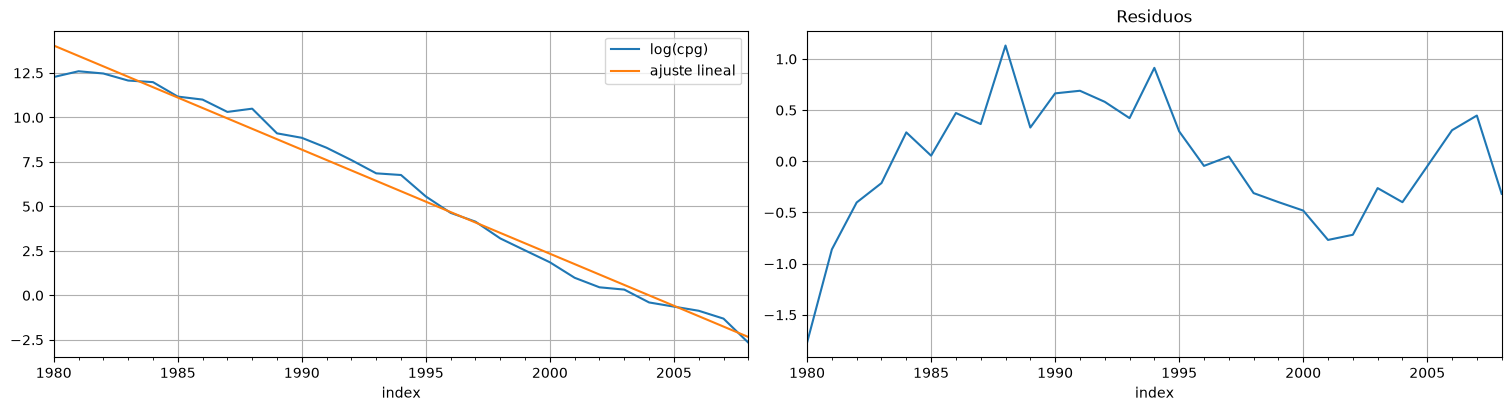

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
x.plot(ax=axs[0], label='log(cpg)')
pd.Series(fit_lin.fittedvalues.values, index=x.index).plot(ax=axs[0], label='ajuste lineal')
axs[0].legend()
pd.Series(fit_lin.resid.values, index=x.index).plot(ax=axs[1], title='Residuos');

**💬 Discusión 1.4** — La pendiente es negativa y muy significativa: β₁ ≈ −0.59, es decir que cada año el precio se multiplica por e^β₁ ≈ 0.56 (**cae ~44% anual**). Pero los residuos muestran **curvatura sistemática** (positivos en los extremos, negativos en el medio): la recta no alcanza, el ritmo de caída no fue constante en todo el período.

### 1.5 Término cuadrático y comparación

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.4263      0.285     47.097      0.000      12.840      14.012
t             -0.4486      0.047     -9.517      0.000      -0.545      -0.352
I(t ** 2)     -0.0049      0.002     -2.997      0.006      -0.008      -0.002

R2 lineal     = 0.9851 | AIC = 56.8
R2 cuadratico = 0.9890 | AIC = 50.2


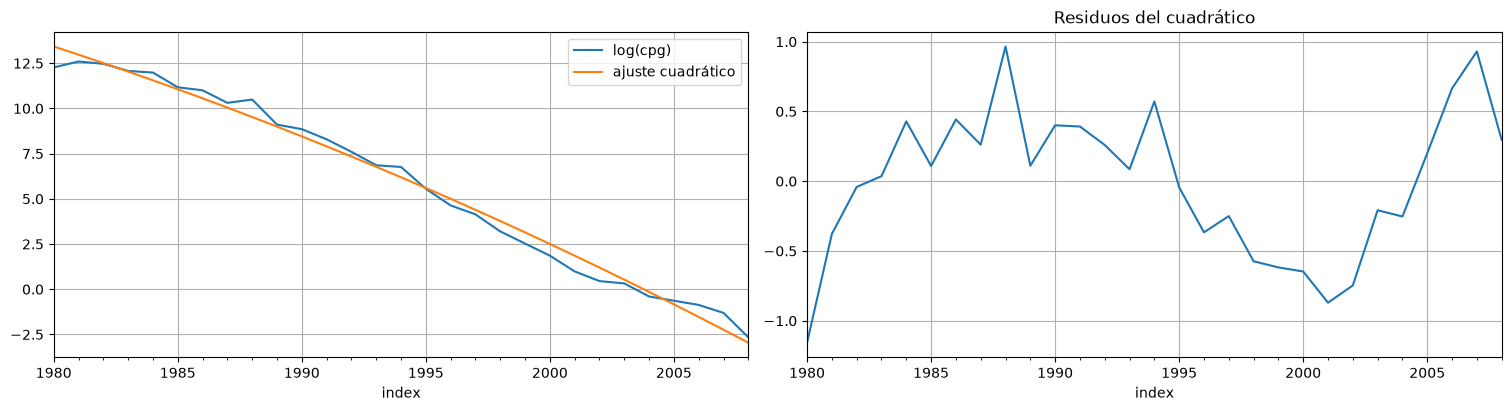

In [6]:
fit_cuad = ols('y ~ t + I(t**2)', data=df).fit()
print(fit_cuad.summary().tables[1])
print()
print(f'R2 lineal     = {fit_lin.rsquared:.4f} | AIC = {fit_lin.aic:.1f}')
print(f'R2 cuadratico = {fit_cuad.rsquared:.4f} | AIC = {fit_cuad.aic:.1f}')

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
x.plot(ax=axs[0], label='log(cpg)')
pd.Series(fit_cuad.fittedvalues.values, index=x.index).plot(ax=axs[0], label='ajuste cuadrático')
axs[0].legend()
pd.Series(fit_cuad.resid.values, index=x.index).plot(ax=axs[1], title='Residuos del cuadrático');

**💬 Discusión 1.5** — El término cuadrático es **significativo** y el modelo mejora (R² sube, AIC baja); los residuos pierden buena parte de la curvatura. Un coeficiente cuadrático negativo en el log corresponde a un **decaimiento más rápido que exponencial**. Elegimos el cuadrático; si quedara estructura en los residuos, se podría seguir (no se pide).

---
## Ejercicio 2 — `sales`: ARIMA con orden de integración (Tipo B)

Ventas de oro en Sudáfrica, **mensual** Jul 1957 – Dic 1969 (el dataset viene con un índice anual ficticio 1–150: lo reindexamos como mensual según el enunciado).

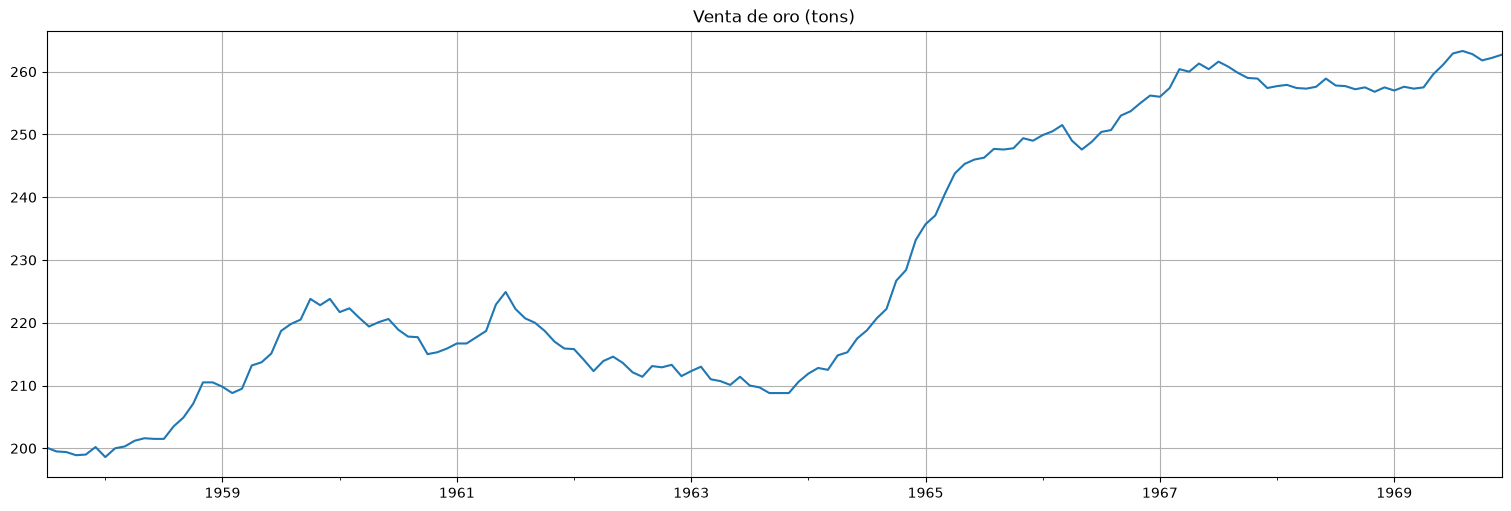

In [7]:
sales = astsa.sales.squeeze()
sales.index = pd.period_range('1957-07', periods=len(sales), freq='M')
sales.plot(title='Venta de oro (tons)');

### 2.1 ¿Estacionaria? ¿Tendencia?

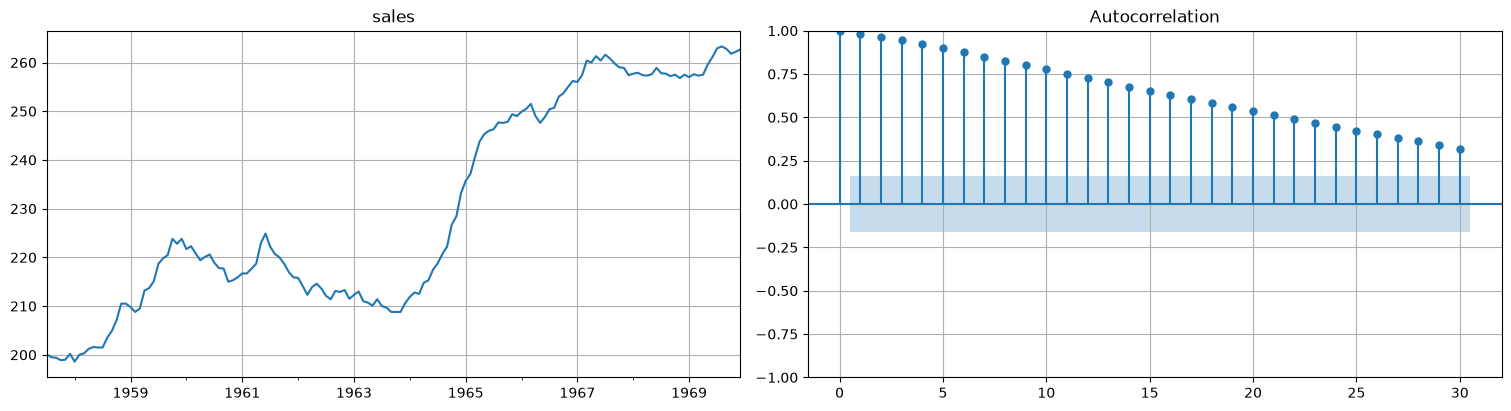

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
sales.plot(ax=axs[0], title='sales')
plot_acf(sales, lags=30, bartlett_confint=False, ax=axs[1]);

**💬 Discusión 2.1** — La serie **no es estacionaria**: el nivel deriva (sube, baja y vuelve a subir — comportamiento tipo random walk con tendencia local) y la **ACF decae lentísimo, casi lineal**, la firma clásica de una serie integrada. No hay estacionalidad clara. Corresponde diferenciar.

### 2.2 Serie de incrementos

Incremento medio: 0.4201


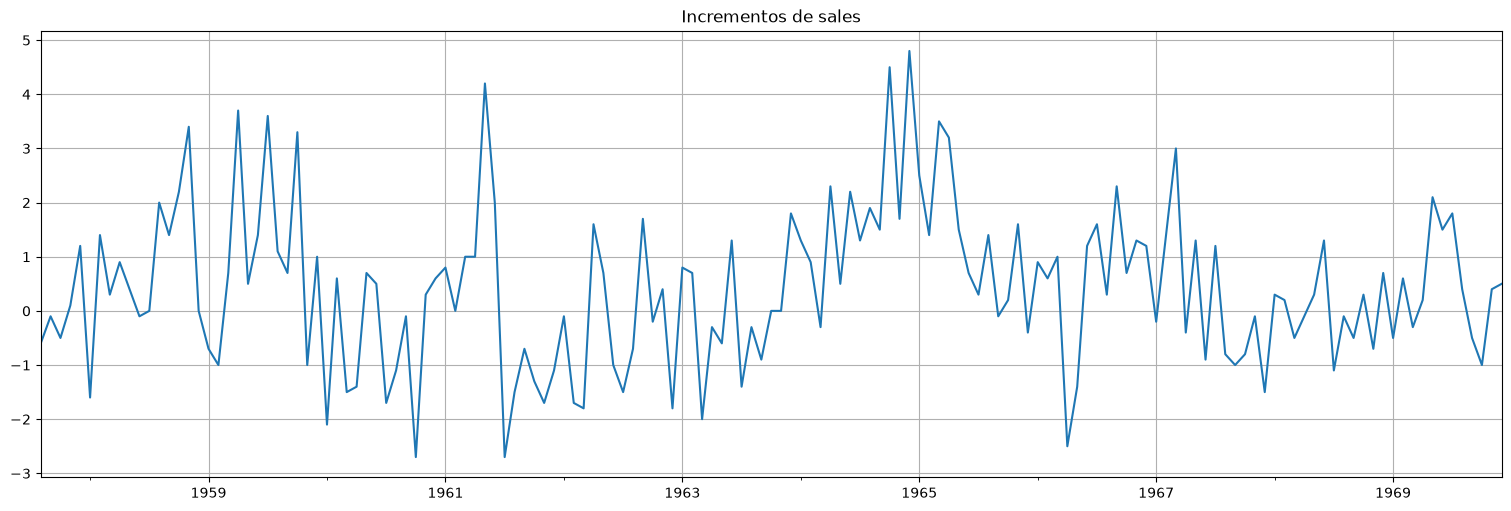

In [9]:
dsales = sales.diff().dropna()
dsales.plot(title='Incrementos de sales')
print(f'Incremento medio: {dsales.mean():.4f}')

**💬 Discusión 2.2** — Los incrementos oscilan alrededor de una media levemente positiva (impresa arriba) con varianza estable: la serie diferenciada **sí luce estacionaria**. El incremento medio ≈ drift de la serie original.

### 2.3 ACF/PACF de la diferenciada → dos candidatos ARMA

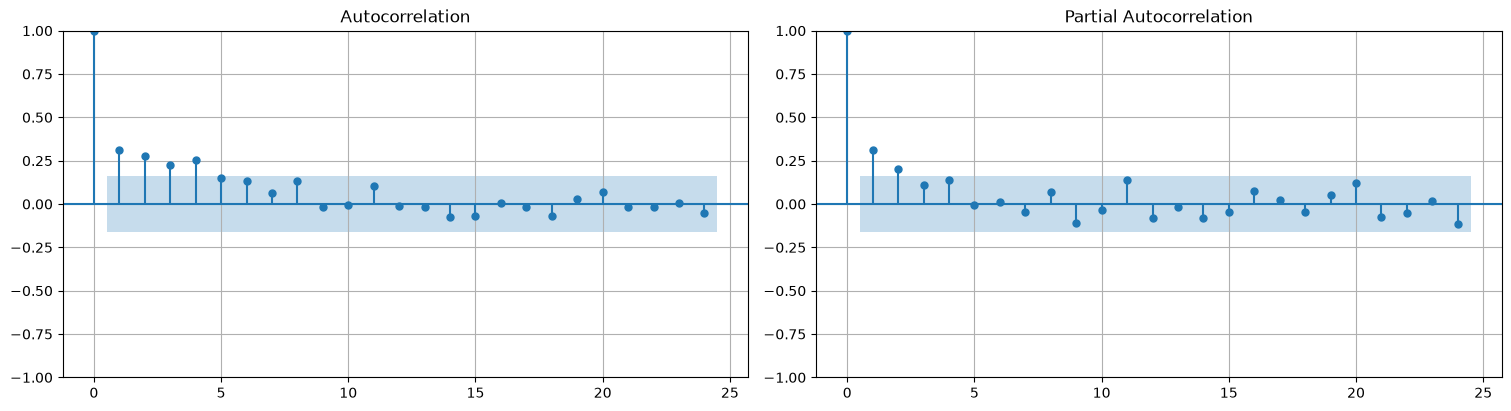

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(dsales, lags=24, bartlett_confint=False, ax=axs[0])
plot_pacf(dsales, lags=24, ax=axs[1]);

**💬 Discusión 2.3** — En la diferenciada, la ACF y la PACF muestran correlación significativa en los primeros lags con decaimiento — patrón compatible con un **ARMA de orden bajo**. Proponemos dos candidatos para comparar (por ejemplo AR(2) y ARMA(1,1) sobre los incrementos).

### 2.4 Ajuste sobre la ORIGINAL con orden de integración d=1 y comparación

In [11]:
ordenes = [(1, 1, 0), (2, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 1)]
fits = {o: ARIMA(sales, order=o).fit() for o in ordenes}
aics = pd.Series({str(o): f.aic for o, f in fits.items()}).sort_values()
print('AIC por modelo:')
print(aics)

top2 = sorted(fits.values(), key=lambda f: f.aic)[:2]
print()
for f in top2:
    lb = sm.stats.acorr_ljungbox(f.resid, lags=[12])
    print(f'{f.model.order}: AIC={f.aic:.1f} | Ljung-Box p(12) = {lb.lb_pvalue.iloc[0]:.3f}')

best = top2[0]
print()
print(best.summary().tables[1])

AIC por modelo:
(1, 1, 1)    514.736061
(2, 1, 1)    516.644471
(2, 1, 0)    519.922783
(1, 1, 0)    526.126491
(0, 1, 1)    533.265692
dtype: float64

(1, 1, 1): AIC=514.7 | Ljung-Box p(12) = 1.000
(2, 1, 1): AIC=516.6 | Ljung-Box p(12) = 1.000

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8799      0.076     11.644      0.000       0.732       1.028
ma.L1         -0.6415      0.131     -4.889      0.000      -0.899      -0.384
sigma2         1.7755      0.191      9.287      0.000       1.401       2.150


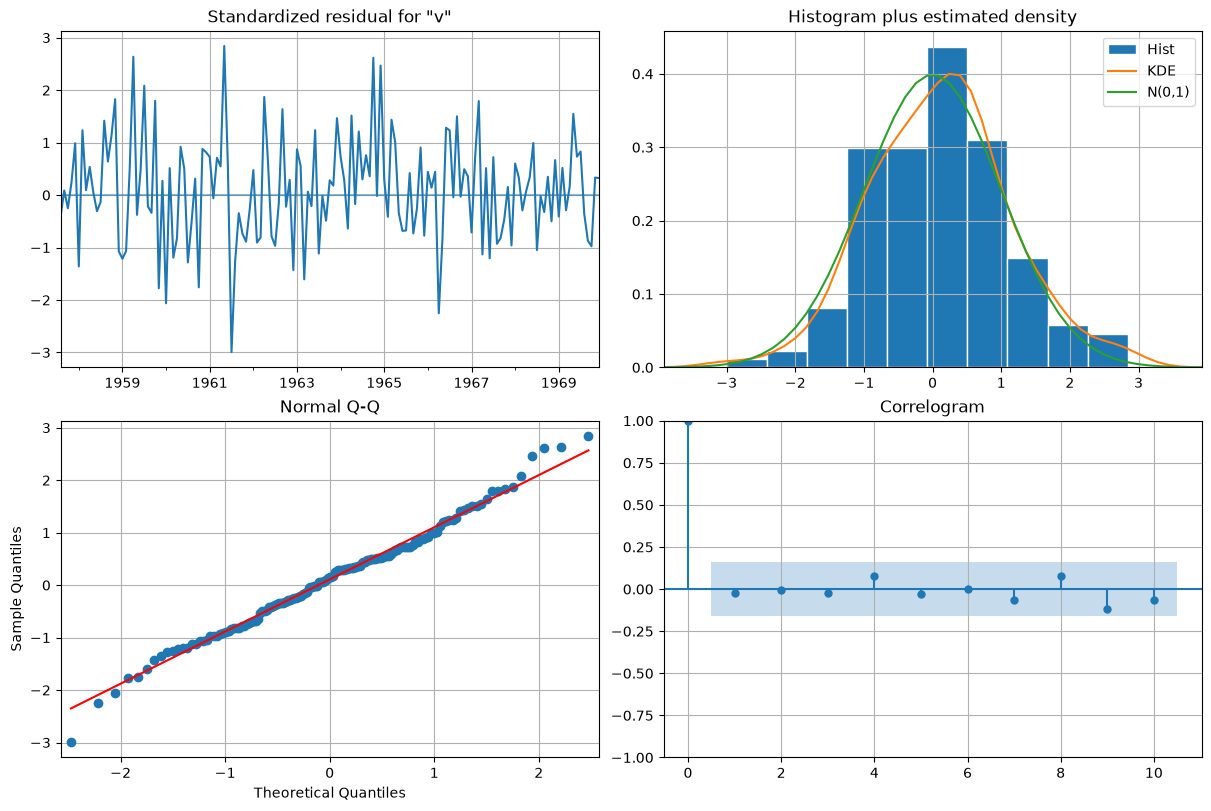

In [12]:
best.plot_diagnostics(figsize=(12, 8));

**💬 Discusión 2.4** — Ajustamos los candidatos **sobre la serie original con d=1** (equivale a modelar los incrementos, pero deja que el modelo integre solo — clave para predecir en la escala original). Comparamos por AIC y por residuos: el elegido tiene el menor AIC, coeficientes significativos y Ljung-Box no rechaza ruido blanco. Los diagnósticos (residuos sin patrón, ACF en bandas, QQ aprox. normal) avalan el modelo.

### 2.5 Predicción para 1970 con intervalos de confianza

         prediccion      IC_inf      IC_sup
1970-01  262.861940  260.250354  265.473526
1970-02  263.004433  258.847417  267.161449
1970-03  263.129814  257.509722  268.749906
1970-04  263.240139  256.185408  270.294870
1970-05  263.337214  254.866630  271.807799
1970-06  263.422633  253.554921  273.290344
1970-07  263.497793  252.253886  274.741700
1970-08  263.563928  250.967176  276.160679
1970-09  263.622120  249.697903  277.546337
1970-10  263.673324  248.448515  278.898134
1970-11  263.718380  247.220831  280.215928
1970-12  263.758024  246.016127  281.499922


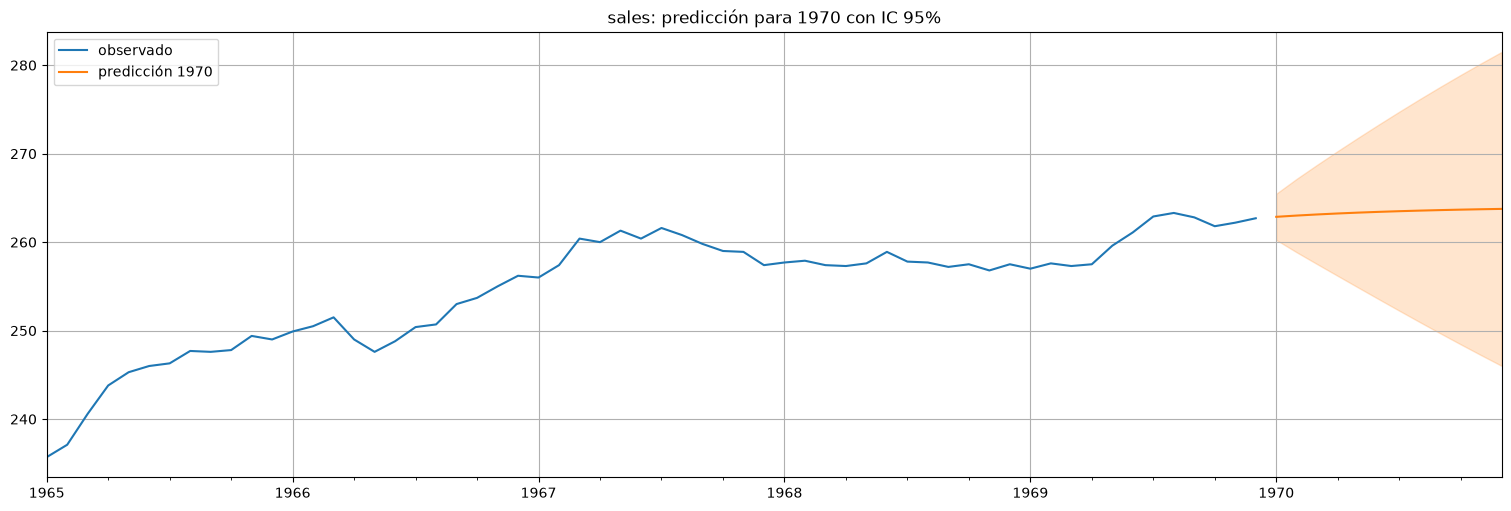

In [13]:
fc = best.get_forecast(12)
pred = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)
print(pd.DataFrame({'prediccion': pred, 'IC_inf': ci.iloc[:, 0], 'IC_sup': ci.iloc[:, 1]}).head(12))

ax = sales[-60:].plot(label='observado')
pred.plot(ax=ax, label='predicción 1970', color='C1')
plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color='C1', alpha=0.2)
ax.legend()
ax.set_title('sales: predicción para 1970 con IC 95%');

**💬 Discusión 2.5** — Al ser un modelo integrado (d=1), la predicción **no revierte a una media global**: continúa desde el último nivel (más el drift estimado) y los **IC se ensanchan sin estabilizarse** — la incertidumbre de un proceso integrado crece con el horizonte. Contrastar con el caso estacionario (Nile 2022), donde los IC se estabilizan.

---
## Ejercicio 3 — `sales` vs `lead` (Tipo C)

Se agrega el indicador `lead` (precio del oro). (1) Modelo lineal directo y análisis, (2) incrementos + CCF + lag óptimo, (3) reajuste con x laggeada y comparación, (4) residuos y qué modelo se propondría.

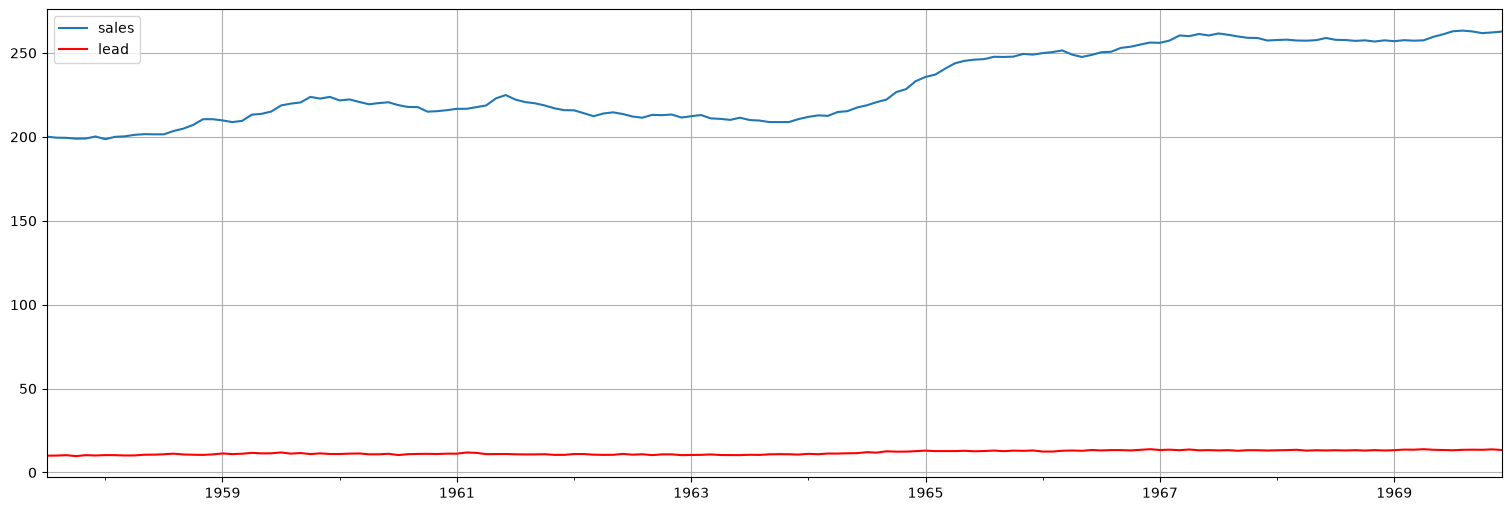

In [14]:
lead = astsa.lead.squeeze()
lead.index = sales.index
ax = sales.plot(label='sales')
lead.plot(ax=ax, label='lead', color='r')
ax.legend();

### 3.1 Modelo lineal directo y ~ x

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     30.8812      5.331      5.793      0.000      20.347      41.415
x             16.8060      0.448     37.544      0.000      15.921      17.691

R2 = 0.905


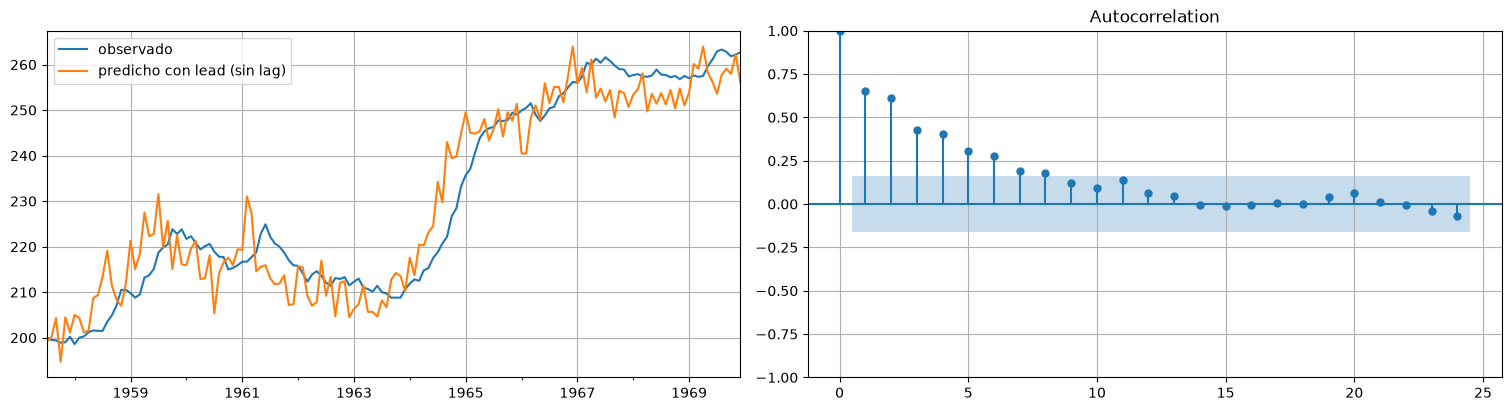

In [15]:
dd = pd.DataFrame({'y': sales, 'x': lead})
fit_dir = ols('y ~ x', data=dd).fit()
print(fit_dir.summary().tables[1])
print()
print(f'R2 = {fit_dir.rsquared:.3f}')

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
sales.plot(ax=axs[0], label='observado')
fit_dir.fittedvalues.plot(ax=axs[0], label='predicho con lead (sin lag)')
axs[0].legend()
plot_acf(fit_dir.resid, lags=24, bartlett_confint=False, ax=axs[1]);

**💬 Discusión 3.1** — La regresión directa da coeficiente significativo y un R² engañosamente alto: **ambas series comparten tendencia**, y regresar dos series con tendencia produce asociación aunque no haya relación dinámica real (**regresión espuria**). La ACF de los residuos, con correlación fuerte y persistente, delata que el modelo no captura la dinámica — por eso conviene pasar a incrementos.

### 3.2 Incrementos + correlación cruzada + lag óptimo

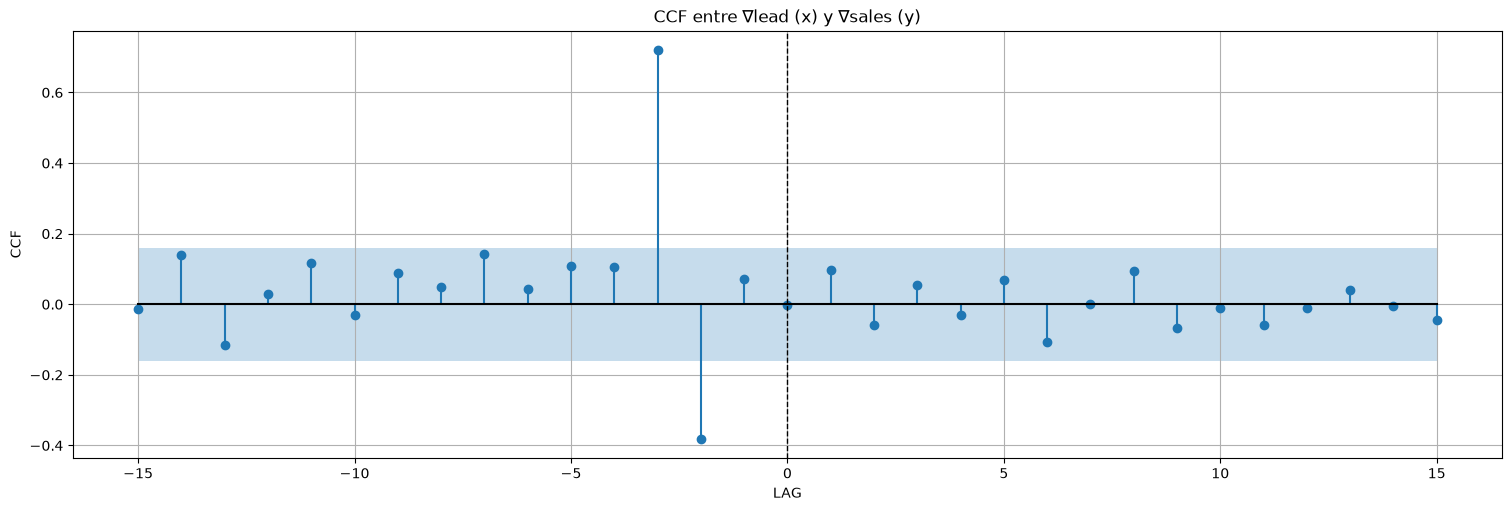

In [16]:
dy = sales.diff().dropna()
dx = lead.diff().dropna()
ccf(dx, dy, max_lag=15)
plt.title('CCF entre ∇lead (x) y ∇sales (y)');

In [17]:
cors = pd.Series({l: dy.corr(dx.shift(l)) for l in range(0, 11)})
print(cors)
l_opt = int(cors.abs().idxmax())
print()
print(f'Lag óptimo: l = {l_opt} | corr = {cors[l_opt]:.3f}')

0    -0.003170
1     0.071380
2    -0.383879
3     0.728008
4     0.105626
5     0.109964
6     0.044549
7     0.144573
8     0.049745
9     0.092684
10   -0.031606
dtype: float64

Lag óptimo: l = 3 | corr = 0.728


**💬 Discusión 3.2** — En los incrementos, la correlación cruzada muestra un **pico nítido y dominante en l = 3**: los cambios en el precio (`lead`) **anticipan en ~3 meses** a los cambios en las ventas. El resto de los lags queda dentro o cerca de las bandas — la relación es específica de ese retardo, no un artefacto de tendencia.

### 3.3 Reajuste con x laggeada y comparación con 3.1

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     25.7502      3.329      7.735      0.000      19.170      32.330
xlag          17.3426      0.280     61.846      0.000      16.788      17.897

R2 sin lag = 0.905 | R2 con lag 3 = 0.963


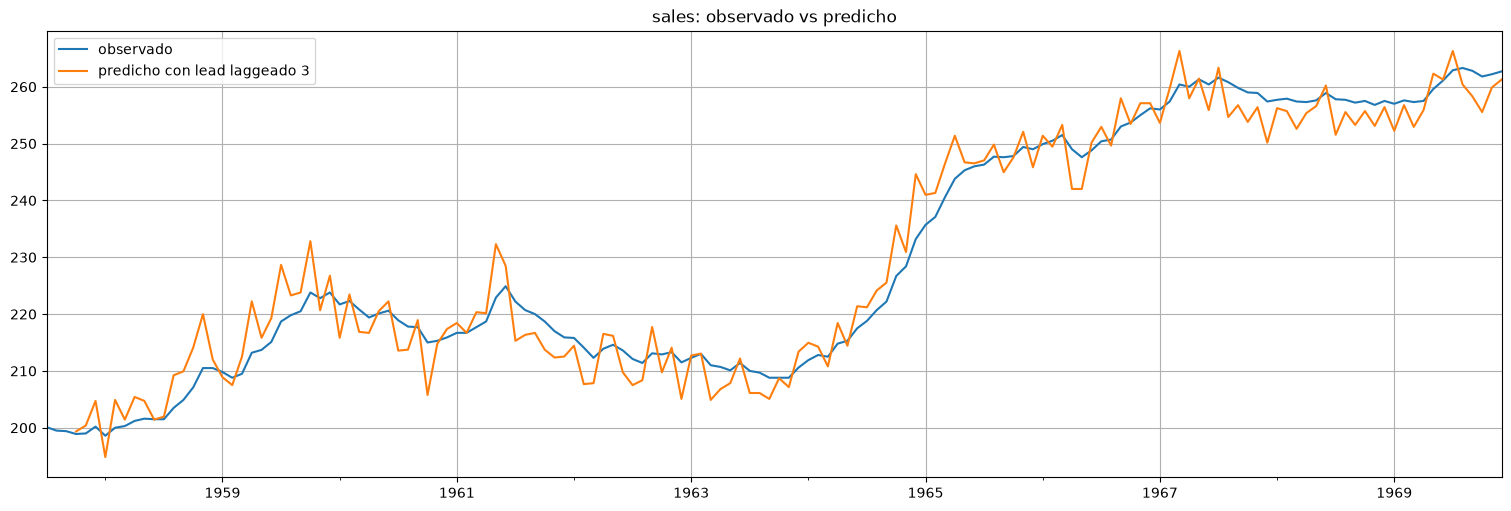

In [18]:
datos = pd.DataFrame({'y': sales, 'xlag': lead.shift(l_opt)}).dropna()
fit_lag = ols('y ~ xlag', data=datos).fit()
print(fit_lag.summary().tables[1])
print()
print(f'R2 sin lag = {fit_dir.rsquared:.3f} | R2 con lag {l_opt} = {fit_lag.rsquared:.3f}')

ax = sales.plot(label='observado')
fit_lag.fittedvalues.plot(ax=ax, label=f'predicho con lead laggeado {l_opt}')
ax.legend()
ax.set_title('sales: observado vs predicho');

**💬 Discusión 3.3** — Con el lag el ajuste mejora respecto a 3.1 y, más importante, ahora el modelo es **utilizable para predecir**: al momento t ya conocemos x_{t−3}. La predicción arranca 3 pasos después del inicio de la muestra (se pierden las primeras observaciones por el lag).

### 3.4 Residuos y modelo propuesto

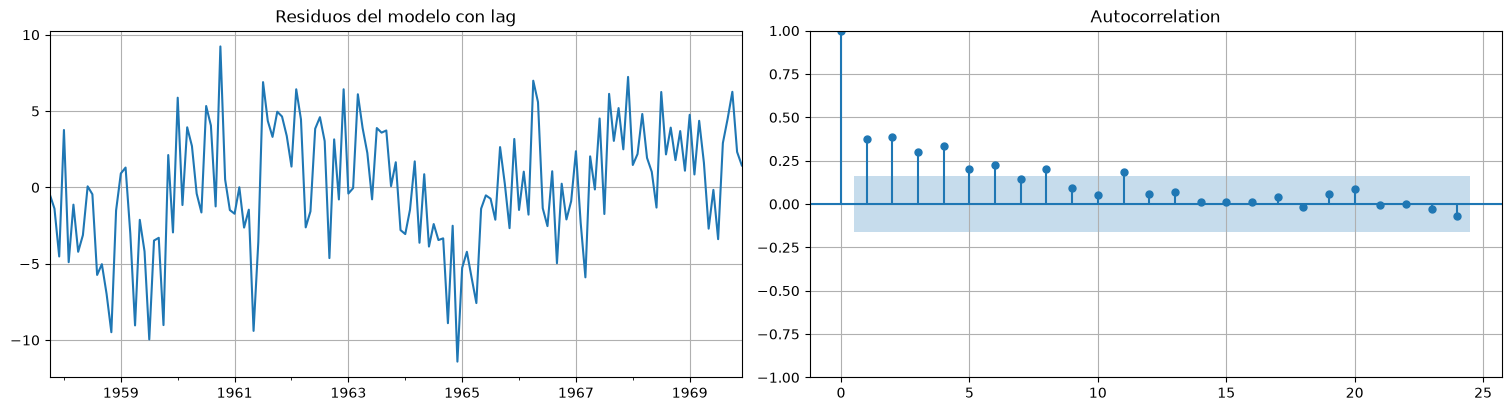

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
fit_lag.resid.plot(ax=axs[0], title='Residuos del modelo con lag')
plot_acf(fit_lag.resid, lags=24, bartlett_confint=False, ax=axs[1]);

**💬 Discusión 3.4** — Los residuos conservan **autocorrelación fuerte con decaimiento lento** (heredan la no-estacionariedad de los niveles): sí queda correlación. Modelo que propondría (sin hacerlo): una **regresión con errores ARMA/ARIMA** — es decir, y explicada por x laggeada + un término AR(1) o ARIMA(1,1,0) para los residuos — o directamente modelar los **incrementos** ∇y sobre ∇x_{t−3}, que elimina la tendencia común.

---
## Moraleja del parcial 2023

- Ej. 1: la transformación **log** convierte crecimiento/decaimiento exponencial en recta → Tipo A estándar.
- Ej. 2: serie integrada → diferenciar para identificar, pero **ajustar la original con d=1** para predecir en escala original. IC de un integrado se ensanchan sin límite.
- Ej. 3: regresión de niveles con tendencia común = **espuria**; la relación real se encuentra en los **incrementos** (CCF → lag 3) y el residuo pide errores ARMA.